# Homework Assignment 3

**Deadline:** 30 March 2026
<br><br>
**Student names:**: Jocelyn Bell Burnell & Erika Böhm-Vitense  ← **PLEASE REPLACE**
<br>
**Total hours spend:** ... h
<br><br>
**Important Remarks:**
<br>
* **Submitting the homework is a compulsory course component. You will not be able to participate in the exam without submitting your homework solutions before the specified deadline.** 
* Making mistakes or not always being able to completely solve an exercise is fine. The goal is to let you interactively explore the concepts from the lecture and identify common problems/misconceptions. If you could not solve/finish a task, please discuss why using markdown cells.
* If you should have any questions please don't hesitate to ask them. This especially includes any questions on (astro)physical aspects of the exercises. You can use the [discussions section](https://ultra.edu.kuleuven.cloud/ultra/courses/_15842_1/engagement) in our Toledo Ultra course. **Please do not give away your solution to problems to other student groups when using the discussions.**
* Document what you are doing in markdown cells. Adding formulas is a good way to make your implementations in code easier to understand.
* Plots have to follow scientific standards. This includes the requirement of axis labels including measurement units if applicable!
* Indicate how much time you spend in total on this assignment.

**Submission Process:**
<br>
* Groups only need to submit a single notebook, there is no need for individual submissions.
* Rename the notebook as `HomeworkAssignment3_FirstnameLastname1_FirstnameLastname2.ipynb` where you insert your names in the filename.
* Send your notebook to both TAs (Dario Fritzewski: dario.fritzewski@kuleuven.be; Reinhold Willcox: reinhold.willcox@kuleuven.be) using the subject line "**Data Analysis Homework Submission 1**". You can make your notebook file smaller by deleting the outputs before submitting. If the notebook should still be too large for an email, please use [WeTransfer](https://wetransfer.com/).

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
%matplotlib inline
from matplotlib import pyplot as plt

# Feel free to change these defaults
plt.rc('font',   size=16)          # controls default text sizes
plt.rc('axes',   titlesize=18)     # fontsize of the axes title
plt.rc('axes',   labelsize=18)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=18)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=18)     # fontsize of the tick labels
plt.rc('legend', fontsize=18)      # legend fontsize
plt.rc('figure', titlesize=18)     # fontsize of the figure title

In [3]:
from IPython.display import Image

---

## Task 1: Electron microscopy

Transmission electron microscopes (TEMs) are capable of making images with much higher resolution than ordinary optical microscopes that use light. TEM microscopes use an electron beam to probe an ultrathin (< 100 nm) specimen leading to images in which one can distinguish features as small as the size of a single atom, which are showing up as noisy "blobs".

In [4]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/TEMimage.csv"
image = np.array(pd.read_csv(url, delimiter=' ', header=None))

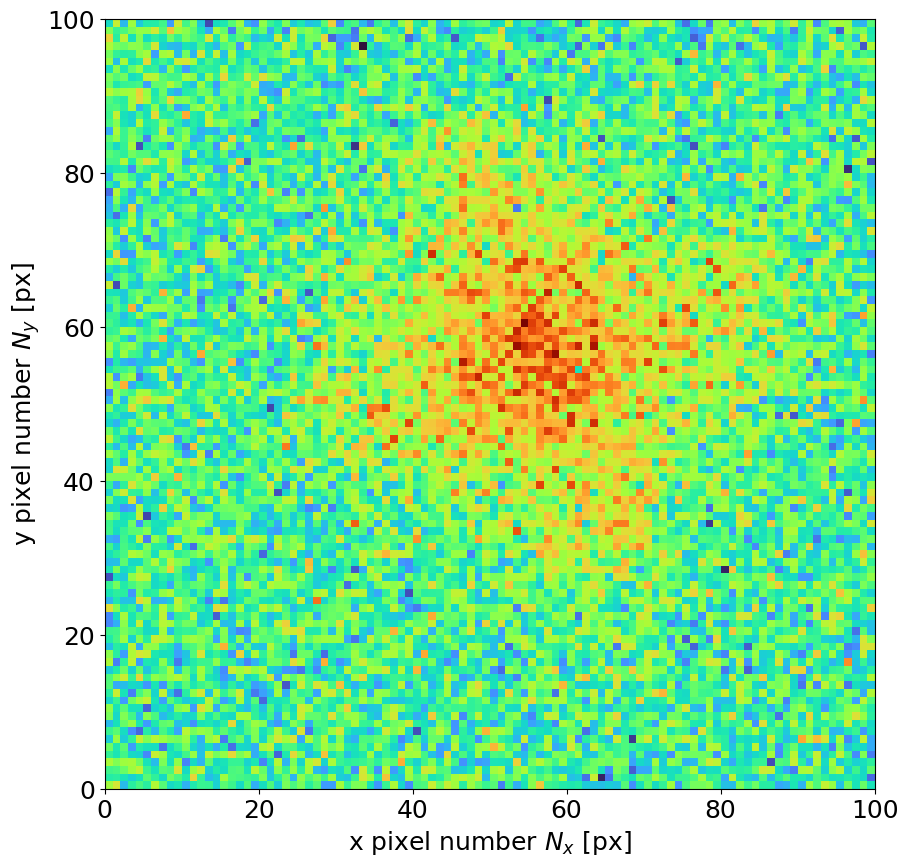

In [5]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
Nrows, Ncols = image.shape
im  = ax.imshow(image, cmap=plt.get_cmap('turbo'), interpolation="nearest", origin='lower', extent=[0,Nrows,0,Ncols])
ax.set_xlabel("x pixel number $N_x$ [px]")
ax.set_ylabel("y pixel number $N_y$ [px]")
plt.show()

The noisy image above shows a part of a lattice structure. The structure consists of 4 identical atoms (faint) on the vertices of a (rotated) square, with an atom of another species (pronounced) in the middle of the square. The structure is embedded in a constant background. You can assume that each of the atoms can be modeled with a spherically-symmetric Gaussian function.

Your tasks for this exercise are the following:

- Perform a non-linear least-squares fit to determine the heights, the (x,y) positions (pixels), and the standard deviations [pixels] of the Gaussian functions, taking into account the constraints of the lattice. Visualize your solution.
- Demonstrate that a model with 5 Gaussians fits the image indeed better than a model with just one Gaussian, despite the extra number of fit parameters.  

**Tip:** if you want to use a regression library that expects 1D arrays instead of the 2D array like the image above, you can use the ravel() function in NumPy to convert the image in a long 1D array. For example:

`image.ravel()`

returns the entire image in a 1D array. The corresponding pixel coordinates can be obtained in a long 1D array with 

```
N=100
x = np.arange(N)
y = np.arange(N)
Xpix, Ypix = np.meshgrid(x, y)
X = Xpix.ravel()
Y = Ypix.ravel()
```

---

## Task 2: Elliptical galaxies

Elliptical galaxies are galaxies that have an ellipsoidal shape and a smooth featureless appearance. A famous example is the galaxy NGC4472 also known as M49, which is located in the constellation of Virgo, about 56 million lightyears away from us. The galaxy is believed to host a massive black hole of more than 500 million solar masses. 

In [6]:
Image(url="https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/M49.jpeg", width=700)

The image above shows the elliptical galaxy NGC4472. Credit: David W. Hogg, Michael R. Blanton, and the Sloan Digital Sky Survey Collaboration.

NGC4472 is part of a cluster of galaxies called the Virgo cluster, which contains more than 1300 galaxies:

In [7]:
Image(url="https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/Virgo_cluster.png", width=700)

The image above shows the Virgo cluster, which was edited so that no foreground stars are visible. Credit: Pablo Carlos Budassi.

As the image of NGC4472 clearly shows, the local surface intensity $I$ of the galaxy clearly decreases from the core to the edge of the galaxy. One of the first attempts to model this behavior was the intensity profile proposed by Hubble in 1930):

$$ I(r) = I_0 \ (1 + r/r_e)^{-2} $$

Here $I(r)$ is the intensity as a function of angular distance $r$, and $I_0$ and $r_e$ are free (fit) parameters. Another model was proposed by Vaucouleurs in 1948:

$$ I(r) = I_0 \ e^{-k [(r/r_e)^{1/4} - 1]} $$

with $k=7.669$, and yet another profile by Sérsic (1968):

$$ I(r) = I_0 \ 10^{-b_n [(r/r_e)^{1/n} -1]} $$

The parameter $r_e$ and in the case of Sérsic's profile also the (real-valued) parameter $n$ can be linked to the structure of the galaxy. In Sérsic's law, $b_n = 0.868 n - 0.142$ for $n\in[0.5, 16.5]$.  

The datasets for this exercise are borrowed from Feigelson & Babu (2012) who in turn extracted it from Kormendy et al. (2009). They contain the observed surface brightness profile of three elliptical galaxies: NGC4472, NGC4551, NGC4406. In practice, not the intensity $I(r)$ itself can be measured, but the surface brightness

$$\mu(r) = \mu_0 - 2.5 \log_{10} I(r) $$

which is expressed in magnitude per square arcsec. The exact unit is not really relevant for this exercise.

In [8]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/NGC4472_profile.csv"
ngc4472 = pd.read_csv(url)

In [9]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/NGC4551_profile.csv"
ngc4551 = pd.read_csv(url)

In [10]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/NGC4406_profile.csv"
ngc4406 = pd.read_csv(url)

In [11]:
ngc4472.head()

,radius,surf_mag
0,3.526,16.917
1,4.015,17.032
2,4.557,17.150
3,4.966,17.239
4,5.491,17.339


The columns in the datasets are:
- **radius**: the radial distance $r$ on the sky from the core of the galaxy [arcsec]
- **surf_mag**: the surface brightness $\mu(r)$ of the galaxy  [mag/arcsec$^2$]

The parameter $\mu_0=26$ for NGC4472 and NGC4451, and $\mu_0= 32$ for NGC4406. 

Your tasks for this exercise are the following:
- Fit the three models mentioned above to these three galaxy datasets. The relevant fit parameters are $I_0$, $r_e$ and $n$.
- Use both the Akaike as well as the Bayesian information criterion to determine which model should be preferred. Quantify how much you prefer one model above the other. Compare the two approaches.
- Diagnose your regression, and verify whether using ordinary non-linear least-squares is indeed justified. If you see something "anomalous" can you speculate what the reason could be?
- Determine $2\sigma$ individual confidence intervals for the parameters $r_e$ and $n$.
- For NGC4472, determine a $2\sigma$ joint confidence interval of $r_e$ and $n$ and visualize it on a plot together with contours of the cost function $S(\mathbf{\theta})$.
- Again for NGC4472, use bootstrapping to determine individual confidence intervals for the parameters $r_e$ and $n$. Think about the best bootstrap sampling method.

---

## Task 3: Supernovae

A supernova is a violent explosion of a star which makes it temporarily so luminous that it can be seen from huge distances.

In [12]:
Image(url="https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/supernovaNGC2525.jpg", width=700)

The picture above shows the spiral galaxy NGC2525, in which a supernova was detected on 15 January 2018. The supernova is the blueish star at the left of the image. Although NGC2525 is located at a distance of 70 million lightyears, the supernova is brighter than any of the foreground stars in our own Milky Way. Image credit: NASA. 

Different types of supernova exist, and this exercise is about Type Ia supernovae, which are the result from a gigantic thermonuclear detonation of a white dwarf star that accreted mass from a neighboring star. A theoretical analysis suggests that all Type Ia supernovae have more or less the same intrinsic brightness. Or, in other words, the apparent brightness together with the expected intrinsic brightness can be used to derive the distance of the supernova, and thus of its host galaxy.

The dataset below is a semi-realistic collection of distances of a $N=100$ synthetic supernova. In practice, astronomers usually work with the distance modulus $\mu$ rather than the actual distance $d$ in parsecs:

$$\mu=5\log_{10}(d)-5$$

but this is not of importance for the remainder of the exercise. The distance moduli are listed as a function of the redshift $z$ of the supernova: the relative shift in wavelength of its spectral lines: 
$$ z = \frac{\lambda_{obs} - \lambda_{emit}}{\lambda_{emit}} $$
because the host galaxy is moving away from us due to the expansion of the universe:

In [13]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/supernova.csv"
data = pd.read_csv(url)

In [14]:
data.head()

,z,mu,sigma
0,0.072804,37.957583,0.621841
1,0.108690,39.052648,0.632607
2,0.174180,40.422952,0.652254
3,0.206391,41.090266,0.661917
4,0.212883,40.380070,0.663865


The columns in the table are:
- **z**: the redshift of the supernova
- **mu**: the distance modulus [mag]
- **sigma**: the uncertainty on the distance modulus [mag]

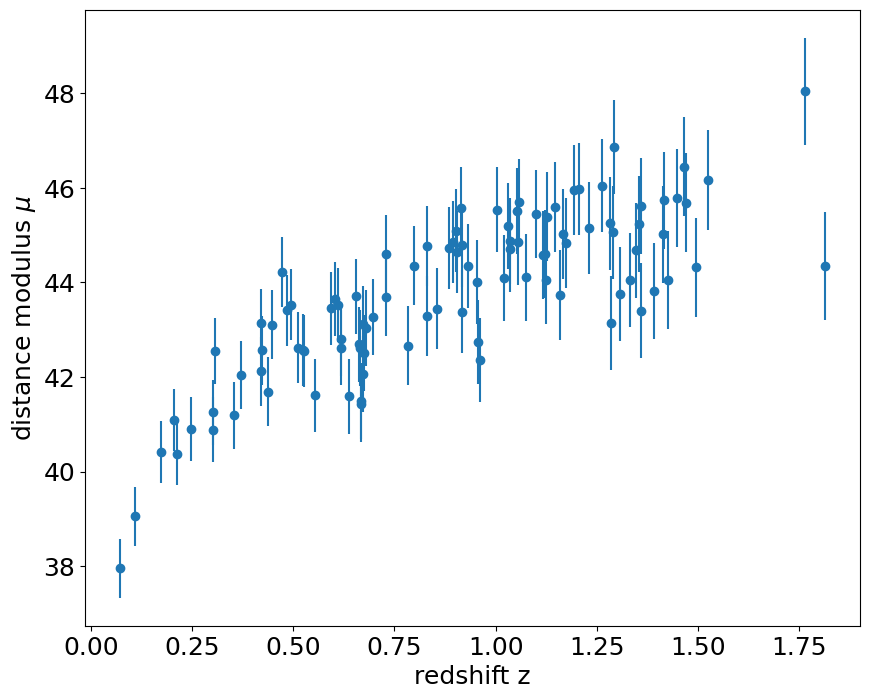

In [15]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
ax.errorbar(data['z'], data['mu'], yerr=data['sigma'], fmt='o')
ax.set_xlabel('redshift z')
ax.set_ylabel('distance modulus $\mu$') 
plt.show()

It would be very useful to have an empirical relation that can be used to predict the distance (or distance modulus) of the supernova given the easily measurable redshift. One possible option is to simply fit a polynomial model

$ \mu(z_n) = \theta_0 + \sum_{k=1}^K \theta_k \ z_n^k + \varepsilon_n $

to the data, and use this model to predict the distance modulus for future supernovae. This will **not** be done in this exercise. Instead of using $x^k$ as base functions, we will be using gaussian base functions:

$ \mu(z_n) = \theta_0 + \sum_{k=1}^K \theta_k e^{-\frac{(z_n - x_k)^2}{2 h^2}} + \varepsilon_n $

This type of regression is called a *gaussian basis function regression*. Here $(z_n, \mu_n=\mu(z_n))$ are the observations.

Your tasks are:
- Fit a model with $K=100$ gaussian basis functions, each with a standard deviation $h=0.14$, and a mean $x_k$ given by the dense grid `x = np.linspace(0.05, 1.85, K)`. 
- Visualize your fit, and plot the fit coefficients $\theta_k$ as a function of $k \in \{1,..,K\}$. Explain what you see.
- Redo the fit with the same model using Ridge and Lasso regression, where you determine in both cases the regularization parameter $\lambda$ using 10-fold cross-validation. 
- Visualize the Ridge and the Lasso fits, and plot again the fit coefficients. Compare their magnitude with the regular fit coefficients.

Another alternative to create an empirical is **kernel regression**, sometimes also called **Nadaraya-Watson regression**. Kernel regression is a non-parametric approach, that does not involve fitting model parameters. As a kernel we will choose a Gaussian kernel, which leads to the following model:

$$ \mu(z_{\rm new}) = \frac{\displaystyle\sum_{n=1}^N \mu_n e^{-\frac{(z_{\rm new} - z_n)^2}{2 h^2}}}{\sum_{n=1}^N e^{-\frac{(z_{\rm new} - z_n)^2}{2 h^2}} } $$

where $(z_n, \mu_n)$ are the observed data. As you can see, this model estimates the distance modulus $\mu$ at an arbitrary value $z_{\rm new}$ by computing a weighted average over all observed $\mu_n$ values. Those $\mu_n$ values that have a corresponding $z_n$ value closer to the requested $z_{\rm new}$ value get a larger weight.

- Compute and plot an empirical relationship between $\mu$ and $z$ using gaussian kernel regression, where you determine an optimal value for $h$ using 10-fold cross-validation. For visualization you can use $z_{\rm new}$ = `np.linspace(0.05, 1.85, 100)`. Compare your result with the one obtained with regularized regression.

---